In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

In [8]:
DATA_PATH = "talabat_enhanced_orders2.csv"
df = pd.read_csv(DATA_PATH)

df.head(10)

,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Delivery_Time,Delivery_Duration_Minutes,City,Payment_Method,Order_Status,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability
0,56795,U4934,991,313,Sushi,5,305.65,2025-06-11 14:37:00,2025-06-11 14:58:00,21,Giza,Wallet,Delivered,Car,30.011739,31.220610,30.019520,31.196654,30.026240,31.200332,2.466822,Medium,Online
1,81167,U8701,151,316,Pizza,4,446.40,2025-06-08 20:13:00,2025-06-08 20:49:00,36,Cairo,Cash,In Transit,Car,30.045413,31.223939,30.062724,31.220663,30.050536,31.237185,1.944823,Low,Online
2,75889,U7689,138,363,Koshary,3,394.50,2025-06-07 03:29:00,2025-06-07 04:20:00,51,Mansoura,Credit Card,Delivered,Car,31.057534,31.366192,31.045638,31.373109,31.020001,31.399328,1.475038,Low,Online
3,34786,U7076,540,258,Burger,4,139.20,2025-06-09 20:49:00,2025-06-09 21:30:00,41,Tanta,Wallet,Cancelled,Bicycle,30.787492,30.993809,30.789228,30.984042,30.805722,30.997262,0.954482,Low,Online
4,38475,U6245,847,110,Salad,2,207.02,2025-06-08 12:05:00,2025-06-08 12:33:00,28,Tanta,Credit Card,Cancelled,Bicycle,30.803427,30.983386,30.768538,30.992124,30.792271,30.987854,3.957460,Medium,Online
5,88329,U3379,454,90,Sandwich,1,125.68,2025-06-02 04:02:00,2025-06-02 04:33:00,31,Alexandria,Cash,Delivered,Car,31.180300,29.922967,31.180552,29.899449,31.211355,29.929651,2.242070,Low,Online
6,79499,U3029,168,479,Sushi,2,243.62,2025-06-15 01:06:00,2025-06-15 01:59:00,53,Giza,Credit Card,Delivered,Motorbike,30.013826,31.215348,30.020233,31.228303,29.995995,31.212204,1.437552,Low,Online
7,27325,U3674,473,321,Fried Chicken,1,149.87,2025-06-04 01:02:00,2025-06-04 01:53:00,51,Tanta,Cash,Cancelled,Car,30.794454,30.998586,30.791487,31.002607,30.799764,31.006845,0.506267,Low,Online
8,73621,U8696,704,42,Pasta,4,562.32,2025-06-14 06:45:00,2025-06-14 07:33:00,48,Zagazig,Credit Card,Delivered,Car,30.573653,31.508104,30.602105,31.519432,30.587649,31.500689,3.336044,Low,Online
9,18180,U3260,458,183,Pasta,5,194.95,2025-06-03 02:50:00,2025-06-03 03:15:00,25,Alexandria,Cash,Delivered,Motorbike,31.193297,29.906175,31.187237,29.913781,31.202042,29.926440,0.988472,Low,Online


In [9]:
print("Shape:", df.shape)
print("\nMissing values per column:")
display(df.isna().sum().to_frame("missing_count").T)

print("\nDuplicate rows:", df.duplicated().sum())

Shape: (25000, 23)

Missing values per column:


,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Delivery_Time,Delivery_Duration_Minutes,City,Payment_Method,Order_Status,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability
missing_count,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0



Duplicate rows: 0


In [10]:
target_col = "Order_Status"
df[target_col].value_counts()

Order_Status
Delivered     10197
Cancelled      9812
In Transit     4991
Name: count, dtype: int64

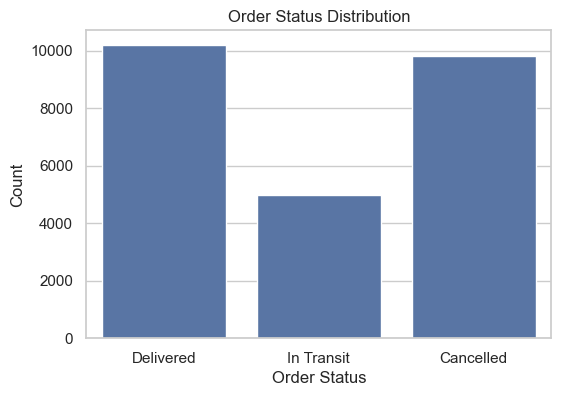

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x=target_col, data=df)
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Count")
plt.show()

In [12]:
df.dtypes

Order_ID                       int64
User_ID                          str
Restaurant_ID                  int64
Driver_ID                      int64
Item_Name                        str
Quantity                       int64
Total_Price                  float64
Order_Time                       str
Delivery_Time                    str
Delivery_Duration_Minutes      int64
City                             str
Payment_Method                   str
Order_Status                     str
Driver_Vehicle                   str
Restaurant_Lat               float64
Restaurant_Lon               float64
Customer_Lat                 float64
Customer_Lon                 float64
Driver_Lat                   float64
Driver_Lon                   float64
Delivery_Distance_km         float64
Traffic_Level                    str
Driver_Availability              str
dtype: object

In [13]:
drop_cols = ["Delivery_Time", "Delivery_Duration_Minutes"]

drop_cols = [c for c in drop_cols if c in df.columns]
df = df.drop(columns=drop_cols)

In [14]:
df_fe = df.copy()

In [15]:
df_fe["Order_Time"] = pd.to_datetime(df_fe["Order_Time"], errors="coerce")

df_fe["order_hour"] = df_fe["Order_Time"].dt.hour
df_fe["order_dayofweek"] = df_fe["Order_Time"].dt.dayofweek
df_fe["is_weekend"] = df_fe["order_dayofweek"].isin([5, 6]).astype(int)

df_fe["is_peak_hour"] = df_fe["order_hour"].isin(list(range(12, 16)) + list(range(19, 24))).astype(int)

df_fe[["Order_Time", "order_hour", "order_dayofweek", "is_weekend", "is_peak_hour"]].head(10)

,Order_Time,order_hour,order_dayofweek,is_weekend,is_peak_hour
0,2025-06-11 14:37:00,14,2,0,1
1,2025-06-08 20:13:00,20,6,1,1
2,2025-06-07 03:29:00,3,5,1,0
3,2025-06-09 20:49:00,20,0,0,1
4,2025-06-08 12:05:00,12,6,1,1
5,2025-06-02 04:02:00,4,0,0,0
6,2025-06-15 01:06:00,1,6,1,0
7,2025-06-04 01:02:00,1,2,0,0
8,2025-06-14 06:45:00,6,5,1,0
9,2025-06-03 02:50:00,2,1,0,0


In [16]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1 = np.radians(lat1); lon1 = np.radians(lon1)
    lat2 = np.radians(lat2); lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

coord_cols = {"Restaurant_Lat", "Restaurant_Lon", "Customer_Lat", "Customer_Lon"}

if coord_cols.issubset(set(df_fe.columns)):
    df_fe["haversine_rest_to_cust_km"] = haversine_km(
        df_fe["Restaurant_Lat"], df_fe["Restaurant_Lon"],
        df_fe["Customer_Lat"], df_fe["Customer_Lon"]
    )
    display(df_fe[["Delivery_Distance_km", "haversine_rest_to_cust_km"]].head(10))
else:
    print("Coordinate columns not found. Skipping Haversine feature.")

,Delivery_Distance_km,haversine_rest_to_cust_km
0,2.466822,2.463521
1,1.944823,1.950558
2,1.475038,1.477900
3,0.954482,0.952771
4,3.957460,3.968334
5,2.242070,2.237553
6,1.437552,1.436513
7,0.506267,0.506320
8,3.336044,3.344290
9,0.988472,0.988730


In [17]:
df_fe["Item_Name"].unique()

<StringArray>
[        'Sushi',         'Pizza',       'Koshary',        'Burger',
         'Salad',      'Sandwich', 'Fried Chicken',         'Pasta',
      'Shawarma']
Length: 9, dtype: str

In [18]:
df_fe["Item_Name"].nunique()

9

In [19]:
df_fe["price_tier"] = pd.cut(
    df_fe["Total_Price"],
    bins=[0, 100, 250, 500, np.inf],
    labels=["low", "medium", "high", "very_high"]
)

df_fe[["Total_Price", "price_tier"]].head(10)

,Total_Price,price_tier
0,305.65,high
1,446.40,high
2,394.50,high
3,139.20,medium
4,207.02,medium
5,125.68,medium
6,243.62,medium
7,149.87,medium
8,562.32,very_high
9,194.95,medium


In [20]:
top_k = 3
top_items = df_fe["Item_Name"].value_counts().head(top_k).index

df_fe["Item_Name_reduced"] = np.where(
    df_fe["Item_Name"].isin(top_items),
    df_fe["Item_Name"],
    "Other"
)

print("Unique Item_Name:", df_fe["Item_Name"].nunique())
print("Unique Item_Name_reduced:", df_fe["Item_Name_reduced"].nunique())

df_fe[["Item_Name", "Item_Name_reduced"]].head(10)

Unique Item_Name: 9
Unique Item_Name_reduced: 4


,Item_Name,Item_Name_reduced
0,Sushi,Other
1,Pizza,Pizza
2,Koshary,Koshary
3,Burger,Burger
4,Salad,Other
5,Sandwich,Other
6,Sushi,Other
7,Fried Chicken,Other
8,Pasta,Other
9,Pasta,Other


In [21]:
drop_cols = [
    "Order_ID", "User_ID", "Restaurant_ID", "Driver_ID",
    "Total_Price", "haversine_rest_to_cust_km",
    "Order_Time", "Item_Name"
]

drop_cols = [c for c in drop_cols if c in df_fe.columns]

X = df_fe.drop(columns=drop_cols + [target_col])
y = df_fe[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)
X.columns

X shape: (25000, 19)
y shape: (25000,)


Index(['Quantity', 'City', 'Payment_Method', 'Driver_Vehicle',
       'Restaurant_Lat', 'Restaurant_Lon', 'Customer_Lat', 'Customer_Lon',
       'Driver_Lat', 'Driver_Lon', 'Delivery_Distance_km', 'Traffic_Level',
       'Driver_Availability', 'order_hour', 'order_dayofweek', 'is_weekend',
       'is_peak_hour', 'price_tier', 'Item_Name_reduced'],
      dtype='str')

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (20000, 19)
Test size: (5000, 19)


In [24]:
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X_train.select_dtypes(include=[np.number, "bool"]).columns.tolist()

print("Categorical columns:\n", categorical_cols, "\n")
print("Numeric columns:\n", numeric_cols)

Categorical columns:
 ['City', 'Payment_Method', 'Driver_Vehicle', 'Traffic_Level', 'Driver_Availability', 'price_tier', 'Item_Name_reduced'] 

Numeric columns:
 ['Quantity', 'Restaurant_Lat', 'Restaurant_Lon', 'Customer_Lat', 'Customer_Lon', 'Driver_Lat', 'Driver_Lon', 'Delivery_Distance_km', 'order_hour', 'order_dayofweek', 'is_weekend', 'is_peak_hour']


/var/folders/ym/wvxj3knn01x2374x1r6yd8f80000gn/T/ipykernel_77986/3433628031.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()


In [25]:
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols),
    ]
)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight=None
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("rf", rf)
])

model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contain

In [26]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

acc_3 = accuracy_score(y_test, y_pred)

print("Accuracy:", round(acc_3, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.4016

Classification Report:
              precision    recall  f1-score   support

   Cancelled       0.40      0.47      0.43      1963
   Delivered       0.41      0.53      0.46      2039
  In Transit       0.13      0.00      0.01       998

    accuracy                           0.40      5000
   macro avg       0.31      0.33      0.30      5000
weighted avg       0.35      0.40      0.36      5000



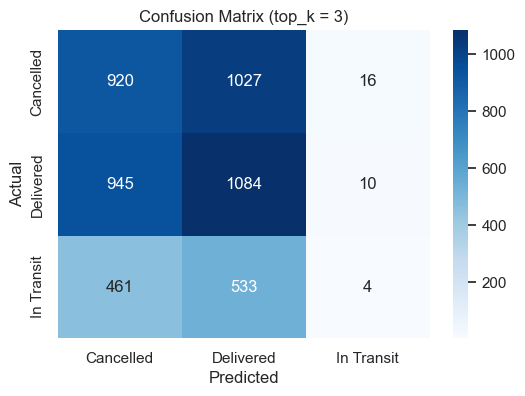

In [27]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)
plt.title("Confusion Matrix (top_k = 3)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [28]:
ohe = model.named_steps["preprocess"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(categorical_cols) if len(categorical_cols) > 0 else np.array([])
all_feature_names = np.concatenate([cat_feature_names, np.array(numeric_cols)])

importances = model.named_steps["rf"].feature_importances_

fi_3 = (
    pd.DataFrame({"feature": all_feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
)

fi_3.head(15)

,feature,importance
33,Delivery_Distance_km,0.091759
32,Driver_Lon,0.090914
31,Driver_Lat,0.090440
30,Customer_Lon,0.090341
29,Customer_Lat,0.089791
27,Restaurant_Lat,0.089683
28,Restaurant_Lon,0.089460
34,order_hour,0.061247
35,order_dayofweek,0.044635
26,Quantity,0.037548


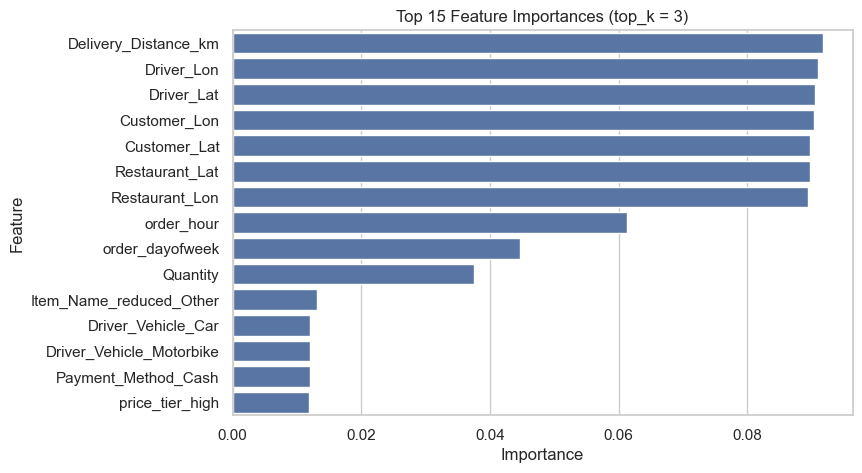

In [29]:
plt.figure(figsize=(8,5))
sns.barplot(data=fi_3.head(15), x="importance", y="feature")
plt.title("Top 15 Feature Importances (top_k = 3)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [30]:
top_k = 5
top_items = df_fe["Item_Name"].value_counts().head(top_k).index

df_fe["Item_Name_reduced"] = np.where(
    df_fe["Item_Name"].isin(top_items),
    df_fe["Item_Name"],
    "Other"
)

print("Unique Item_Name:", df_fe["Item_Name"].nunique())
print("Unique Item_Name_reduced:", df_fe["Item_Name_reduced"].nunique())

df_fe[["Item_Name", "Item_Name_reduced"]].head(10)

Unique Item_Name: 9
Unique Item_Name_reduced: 6


,Item_Name,Item_Name_reduced
0,Sushi,Other
1,Pizza,Pizza
2,Koshary,Koshary
3,Burger,Burger
4,Salad,Other
5,Sandwich,Other
6,Sushi,Other
7,Fried Chicken,Other
8,Pasta,Pasta
9,Pasta,Pasta


In [31]:
drop_cols = [
    "Order_ID", "User_ID", "Restaurant_ID", "Driver_ID",
    "Total_Price", "haversine_rest_to_cust_km",
    "Order_Time", "Item_Name"
]

drop_cols = [c for c in drop_cols if c in df_fe.columns]

X = df_fe.drop(columns=drop_cols + [target_col])
y = df_fe[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (25000, 19)
y shape: (25000,)


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [33]:
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X_train.select_dtypes(include=[np.number, "bool"]).columns.tolist()

/var/folders/ym/wvxj3knn01x2374x1r6yd8f80000gn/T/ipykernel_77986/1809542982.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()


In [34]:
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols),
    ]
)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight=None
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("rf", rf)
])

In [35]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

acc_5 = accuracy_score(y_test, y_pred)

print("Accuracy:", round(acc_5, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.399

Classification Report:
              precision    recall  f1-score   support

   Cancelled       0.39      0.45      0.42      1963
   Delivered       0.41      0.54      0.47      2039
  In Transit       0.10      0.00      0.01       998

    accuracy                           0.40      5000
   macro avg       0.30      0.33      0.30      5000
weighted avg       0.34      0.40      0.36      5000



In [36]:
ohe = model.named_steps["preprocess"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(categorical_cols) if len(categorical_cols) > 0 else np.array([])
all_feature_names = np.concatenate([cat_feature_names, np.array(numeric_cols)])

importances = model.named_steps["rf"].feature_importances_

fi_5 = (
    pd.DataFrame({"feature": all_feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
)

fi_5.head(15)

,feature,importance
35,Delivery_Distance_km,0.089917
33,Driver_Lat,0.088050
32,Customer_Lon,0.088024
34,Driver_Lon,0.087405
30,Restaurant_Lon,0.087067
29,Restaurant_Lat,0.086809
31,Customer_Lat,0.086776
36,order_hour,0.060363
37,order_dayofweek,0.044288
28,Quantity,0.036936


In [37]:
top_k = 6
top_items = df_fe["Item_Name"].value_counts().head(top_k).index

df_fe["Item_Name_reduced"] = np.where(
    df_fe["Item_Name"].isin(top_items),
    df_fe["Item_Name"],
    "Other"
)

print("Unique Item_Name:", df_fe["Item_Name"].nunique())
print("Unique Item_Name_reduced:", df_fe["Item_Name_reduced"].nunique())

df_fe[["Item_Name", "Item_Name_reduced"]].head(10)

Unique Item_Name: 9
Unique Item_Name_reduced: 7


,Item_Name,Item_Name_reduced
0,Sushi,Other
1,Pizza,Pizza
2,Koshary,Koshary
3,Burger,Burger
4,Salad,Other
5,Sandwich,Sandwich
6,Sushi,Other
7,Fried Chicken,Other
8,Pasta,Pasta
9,Pasta,Pasta


In [38]:
drop_cols = [
    "Order_ID", "User_ID", "Restaurant_ID", "Driver_ID",
    "Total_Price", "haversine_rest_to_cust_km",
    "Order_Time", "Item_Name"
]

drop_cols = [c for c in drop_cols if c in df_fe.columns]

X = df_fe.drop(columns=drop_cols + [target_col])
y = df_fe[target_col]

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [40]:
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X_train.select_dtypes(include=[np.number, "bool"]).columns.tolist()

/var/folders/ym/wvxj3knn01x2374x1r6yd8f80000gn/T/ipykernel_77986/1809542982.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()


In [41]:
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols),
    ]
)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight=None
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("rf", rf)
])

In [42]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

acc_6 = accuracy_score(y_test, y_pred)

print("Accuracy:", round(acc_6, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.3988

Classification Report:
              precision    recall  f1-score   support

   Cancelled       0.39      0.46      0.42      1963
   Delivered       0.41      0.53      0.46      2039
  In Transit       0.19      0.01      0.01       998

    accuracy                           0.40      5000
   macro avg       0.33      0.33      0.30      5000
weighted avg       0.36      0.40      0.36      5000



In [43]:
ohe = model.named_steps["preprocess"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(categorical_cols) if len(categorical_cols) > 0 else np.array([])
all_feature_names = np.concatenate([cat_feature_names, np.array(numeric_cols)])

importances = model.named_steps["rf"].feature_importances_

fi_6 = (
    pd.DataFrame({"feature": all_feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
)

fi_6.head(15)

,feature,importance
36,Delivery_Distance_km,0.088338
34,Driver_Lat,0.086632
35,Driver_Lon,0.086557
33,Customer_Lon,0.086496
30,Restaurant_Lat,0.086352
31,Restaurant_Lon,0.086213
32,Customer_Lat,0.085963
37,order_hour,0.059431
38,order_dayofweek,0.043510
29,Quantity,0.036782


In [44]:
comparison_df = pd.DataFrame({
    "top_k": [3, 5, 6],
    "accuracy": [acc_3, acc_5, acc_6]
})

comparison_df

,top_k,accuracy
0,3,0.4016
1,5,0.3990
2,6,0.3988


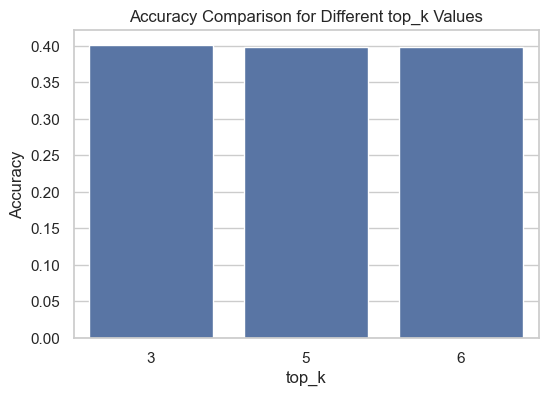

In [45]:
plt.figure(figsize=(6,4))
sns.barplot(data=comparison_df, x="top_k", y="accuracy")
plt.title("Accuracy Comparison for Different top_k Values")
plt.xlabel("top_k")
plt.ylabel("Accuracy")
plt.show()

In [46]:
print("Top 15 features for top_k = 3")
display(fi_3.head(15))

print("Top 15 features for top_k = 5")
display(fi_5.head(15))

print("Top 15 features for top_k = 6")
display(fi_6.head(15))

Top 15 features for top_k = 3


,feature,importance
33,Delivery_Distance_km,0.091759
32,Driver_Lon,0.090914
31,Driver_Lat,0.090440
30,Customer_Lon,0.090341
29,Customer_Lat,0.089791
27,Restaurant_Lat,0.089683
28,Restaurant_Lon,0.089460
34,order_hour,0.061247
35,order_dayofweek,0.044635
26,Quantity,0.037548


Top 15 features for top_k = 5


,feature,importance
35,Delivery_Distance_km,0.089917
33,Driver_Lat,0.088050
32,Customer_Lon,0.088024
34,Driver_Lon,0.087405
30,Restaurant_Lon,0.087067
29,Restaurant_Lat,0.086809
31,Customer_Lat,0.086776
36,order_hour,0.060363
37,order_dayofweek,0.044288
28,Quantity,0.036936


Top 15 features for top_k = 6


,feature,importance
36,Delivery_Distance_km,0.088338
34,Driver_Lat,0.086632
35,Driver_Lon,0.086557
33,Customer_Lon,0.086496
30,Restaurant_Lat,0.086352
31,Restaurant_Lon,0.086213
32,Customer_Lat,0.085963
37,order_hour,0.059431
38,order_dayofweek,0.043510
29,Quantity,0.036782
